# Data description
| Признак | Описание | Тип данных |
|----------|----------|----------|
| SeriousDlqin2yrs | Просрочка платежа на 90 дней или больше  | Y/N |
| RevolvingUtilizationOfUnsecuredLines | Общий остаток средств на кредитных картах и личных кредитных линиях, за исключением операций с недвижимостью и без рассрочки платежа, таких как автокредиты, разделенный на сумму кредитных лимитов | percentage |
| age | Возраст заемщика в годах |	integer |
| NumberOfTime30-59DaysPastDueNotWorse	| Количество раз за последние 2 года заемщик просрочивал платеж на 30-59 дней, но не хуже	| integer |
| DebtRatio	| Ежемесячные выплаты по долгам, алиментам, расходы на проживание, разделенные на ежемесячный валовой доход |	percentage |
| MonthlyIncome	| Ежемесячный доход	| real |
|NumberOfOpenCreditLinesAndLoans	| Количество открытых кредитов (например, автокредит в рассрочку или ипотека) и кредитных линий (например, кредитные карты) | integer |
|NumberOfTimes90DaysLate	| Количество раз, когда заемщик просрочил платеж на 90 дней или более	| integer |
|NumberRealEstateLoansOrLines	| Количество ипотечных кредитов и займов на недвижимость, включая кредитные линии на приобретение жилья	| integer |
|NumberOfTime60-89DaysPastDueNotWorse	| Количество раз за последние 2 года заемщик просрочивал платеж на 60-89 дней, но не хуже	| integer |
|NumberOfDependents	| Количество иждивенцев в семье, не считая их самих (супруг(а), дети и т.д.)	| integer |


**Target: SeriousDlqin2yrs**

# Анализ данных

In [ ]:
import pandas as pd

DATA = pd.read_csv('data_server/cs-training.csv')

RANDOM_STATE = 42
#MLFLOW_URL = 'http://localhost:5050'

In [2]:
DATA.head(3)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0


In [3]:
DATA.drop(columns='Unnamed: 0', inplace=True)

In [4]:
DATA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

В признаках **MonthlyIncome** и **NumberOfDependents** есть много пропущенных значений. Заполним их дальше по ноутбуку.

In [5]:
DATA.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


В данных также присутствуют признаки, которые могут давать схожую информацию: **NumberOfTime30-59DaysPastDueNotWorse**, **NumberOfTimes90DaysLate** и **NumberOfTime60-89DaysPastDueNotWorse** или **NumberOfOpenCreditLinesAndLoans** и **NumberRealEstateLoansOrLines**. Посмотрим на их корреляцию по ходу анализа данных.

Также, если мы выделим возраст, который выходит за пределы 18-100 лет, то сможем заметить, что в данных есть явный выброс с возрастом 0 лет, исправим его в зависимости от распределения значений этого признака. Возраст больше 100 лет возможен, так что не будем засчитывать такие значения за выбросы.

In [10]:
DATA.loc[DATA['age'] < 18]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents


In [7]:
DATA.loc[DATA['age'] > 100]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
7763,0,0.069167,101,0,50.000000,NaN,2,0,0,0,0.0
19884,0,1.000000,103,0,0.000000,1600.0,3,0,0,0,0.0
25561,0,0.009866,102,0,0.002424,3300.0,3,0,0,0,0.0
40007,0,0.064748,107,0,939.000000,NaN,9,0,1,0,0.0
56761,0,0.003469,105,0,2.000000,NaN,4,0,0,0,NaN
57967,0,0.001397,103,0,1798.500000,1.0,11,0,2,0,0.0
90937,0,0.000000,102,0,0.000000,NaN,12,0,0,0,0.0
93813,0,0.025780,101,0,0.013797,1666.0,5,0,0,0,0.0
96450,0,0.109642,102,0,0.273844,3417.0,7,0,0,0,1.0
105790,0,0.109307,109,0,2141.000000,NaN,17,0,1,0,NaN


# Итог анализа:

1) Исправить выброс с нулевым возрастом

2) Заполнить пропуски в **NumberOfDependents**

3) Заполнить пропущенные значения в **MonthlyIncome**

4) Обработать зависимость признаков **NumberOfOpenCreditLinesAndLoans** и **NumberRealEstateLoansOrLines**

5) Обработать зависимость признаков **NumberOfTime30-59DaysPastDueNotWorse**, **NumberOfTimes90DaysLate** и **NumberOfTime60-89DaysPastDueNotWorse**

# Обработка данных

## 1) Исправить выброс с нулевым возрастом

Посмотрим на распределение возраста клиентов

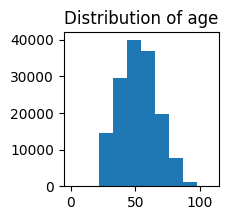

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 2))
plt.hist(DATA['age'])
plt.title('Distribution of age')
plt.show()

Распределение схоже с нормальным с вполне четким видом колокола. Исходя из распределения заполним выбросы средним возрастом, поскольку такая замена не повлияет на выборку:

In [9]:
mean_age = int(DATA['age'].mean())

DATA.loc[DATA['age'] < 18] = mean_age

In [16]:
mean_age

52

## 2) Заполнить пропуски в **NumberOfDependents**

In [11]:
DATA['NumberOfDependents'].value_counts(dropna=False)

NumberOfDependents
0.0     86902
1.0     26316
2.0     19521
3.0      9483
NaN      3924
4.0      2862
5.0       746
6.0       158
7.0        51
8.0        24
10.0        5
9.0         5
20.0        1
52.0        1
13.0        1
Name: count, dtype: int64

Поскольку признак может оказаться полезным, заполним пропуски. 

Заполнение пропусков при помощи другой модели не является рациональным решением, так как логичной зависимости между кредитной информацией о клиенте и количеством иждивенцев в семье не может существовать. 
Пропуски заполним модой:

In [12]:
mode_dependents = DATA['NumberOfDependents'].mode()[0]

DATA['NumberOfDependents'] = DATA['NumberOfDependents'].fillna(mode_dependents).astype(int)

## 3) Заполнить пропущенные значения в **MonthlyIncome**

In [14]:
DATA['MonthlyIncome'].value_counts(dropna=False)

MonthlyIncome
NaN        29731
5000.0      2757
4000.0      2106
6000.0      1933
3000.0      1758
           ...  
16084.0        1
10523.0        1
55250.0        1
9242.0         1
7647.0         1
Name: count, Length: 13596, dtype: int64

Пропусков много, но признак может быть очень полезным для предсказаний. Заполнять пропуски одним значением будет простым, но некорректным решением, ведь ежемесячный доход клиента вполне можно предсказать по кредитной информации. Это позволит сохранить информацию в данных без сильного искажения, что важно для значимых признаков.

Заполним пропуски предсказаниями другой модели:

In [15]:
X_instance = DATA.loc[DATA['MonthlyIncome'].notna()].drop(columns=['MonthlyIncome', 'SeriousDlqin2yrs'])
X_empty = DATA.loc[DATA['MonthlyIncome'].isna()].drop(columns=['MonthlyIncome', 'SeriousDlqin2yrs'])

y_instance = DATA.loc[DATA['MonthlyIncome'].notna(), 'MonthlyIncome']

Выберем модель для предсказания ежемесячного дохода. Основной метрикой будет MSE, так как нам важно штрафовать модель за большие ошибки, поскольку мы добиваемся максимально возможной точности. Для сравнения моделей между собой воспользуемся R2, чтобы оценить их относительно объясненной дисперсией.

In [ ]:
import mlflow
import os
import optuna
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

os.environ['USER'] = 'Maxim Balabanov'

mlflow.set_tracking_uri(MLFLOW_URL)
mlflow.set_experiment('Regressor for MonthlyIncome')

Проверим гипотезу, что ежемесячный доход имеет линейную зависимость от остальных признаков. 

К примеру:
- Чем ближе возраст клиента к среднему (45 - 55 лет), тем выше его заработок. Клиент имеет стаж/опыт работы, может быть на высокой должности и т.д.

- Чем меньше случаев, когда клиент просрочивал платеж, тем меньше вероятности, что клиент часто без денег. А это может говорить о способности клиента оплачивать свои долги, что соответствует стабильному и высокому заработку.

- Если у клиента мало или нет открытых кредитов, значит, его ежемесячный доход позволяет оплачивать покупки сразу, что свидетельствует о высокой заработной плате.

- И прочее

### Линейные модели

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Linear Regression
def linear_objective(trial):
    with mlflow.start_run(run_name=f'Linear_trial_{trial.number}', nested=True):
        
        with_mean = trial.suggest_categorical('with_mean', [True, False])
        with_std = trial.suggest_categorical('with_std', [True, False])
        degree = trial.suggest_int('degree', 1, 3)
        
        mlflow.log_params({
            'with_mean': with_mean,
            'with_std': with_std,
            'degree': degree
        })

        pipeline = Pipeline([
        ('Scaler', StandardScaler(with_mean=with_mean, with_std=with_std)),
        ('Polynomial Features', PolynomialFeatures(degree=degree)),
        ('Model', LinearRegression())
        ])
        
        preds = cross_val_predict(pipeline, X_instance, y_instance, cv=3)
        mse = mean_squared_error(y_instance, preds)
        r2 = r2_score(y_instance, preds)
        
        mlflow.log_metrics({
            'MSE': mse,
            'R2': r2
        }, step=trial.number)
        
        return mse

# Lasso
def lasso_objective(trial):
    with mlflow.start_run(run_name=f'Lasso_trial_{trial.number}', nested=True):
        
        with_mean = trial.suggest_categorical('with_mean', [True, False])
        with_std = trial.suggest_categorical('with_std', [True, False])
        degree = trial.suggest_int('degree', 1, 3)
        
        alpha = trial.suggest_float('alpha', 0.01, 1)
        
        mlflow.log_params({
            'with_mean': with_mean,
            'with_std': with_std,
            'alpha': alpha,
            'degree': degree
        })
        
        pipeline = Pipeline([
        ('Scaler', StandardScaler(with_mean=with_mean, with_std=with_std)),
        ('Polynomial Features', PolynomialFeatures(degree=degree)),
        ('Model', Lasso(alpha=alpha, random_state=RANDOM_STATE))
        ])
        
        preds = cross_val_predict(pipeline, X_instance, y_instance, cv=3)
        mse = mean_squared_error(y_instance, preds)
        r2 = r2_score(y_instance, preds)
        
        mlflow.log_metrics({
            'MSE': mse,
            'R2': r2
        }, step=trial.number)
        
        return mse

# Ridge
def ridge_objective(trial):
    with mlflow.start_run(run_name=f'Ridge_trial_{trial.number}', nested=True):
        
        with_mean = trial.suggest_categorical('with_mean', [True, False])
        with_std = trial.suggest_categorical('with_std', [True, False])
        degree = trial.suggest_int('degree', 1, 3)
        
        alpha = trial.suggest_float('alpha', 0.01, 1)
        
        mlflow.log_params({
            'with_mean': with_mean,
            'with_std': with_std,
            'alpha': alpha,
            'degree': degree
        })
        
        pipeline = Pipeline([
        ('Scaler', StandardScaler(with_mean=with_mean, with_std=with_std)),
        ('Polynomial Features', PolynomialFeatures(degree=degree)),
        ('Model', Ridge(alpha=alpha))
        ])
        
        preds = cross_val_predict(pipeline, X_instance, y_instance, cv=3)
        mse = mean_squared_error(y_instance, preds)
        r2 = r2_score(y_instance, preds)
        
        mlflow.log_metrics({
            'MSE': mse,
            'R2': r2
        }, step=trial.number)
        
        return mse

In [ ]:
#Linear Regression
with mlflow.start_run(run_name='Linear Regressor'):
    study = optuna.create_study(direction='minimize')
    study.optimize(linear_objective, n_trials=20)
    mlflow.log_metric('mse_best', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

#Lasso
with mlflow.start_run(run_name='Lasso Regressor'):
    study = optuna.create_study(direction='minimize')
    study.optimize(lasso_objective, n_trials=20)
    mlflow.log_metric('mse_best', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

#Ridge
with mlflow.start_run(run_name='Ridge Regressor'):
    study = optuna.create_study(direction='minimize')
    study.optimize(ridge_objective, n_trials=20)
    mlflow.log_metric('mse_best', study.best_value)
    mlflow.log_params(study.best_params)

    mlflow.set_tag('Optimizer', 'Optuna')

### Нелинейные модели

Проверим гипотезу, что ежемесячный доход имеет нелинейную зависимость от остальных признаков. 

Признак может иметь более сложные зависимости, чем прямая или обратная. Нельзя точно сказать, что увеличение/уменьшение одного признака повлечет за собой увеличение/уменьшение заполняемого признака. 

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

def neighbors_objective(trial):
    with mlflow.start_run(run_name=f'KNeighbors_trial_{trial.number}', nested=True):
        
        n_neighbors = trial.suggest_int('n_neighbors', 2, 50)
        weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
        algorithm = trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute'])
        
        mlflow.log_params({
            'n_neighbors': n_neighbors,
            'weights': weights,
            'algorithm': algorithm
        })

        model = KNeighborsRegressor(
            n_neighbors=n_neighbors,
            weights=weights,
            algorithm=algorithm
        )
        
        preds = cross_val_predict(model, X_instance, y_instance, cv=3)
        mse = mean_squared_error(y_instance, preds)
        r2 = r2_score(y_instance, preds)
        
        mlflow.log_metrics({
            'MSE': mse,
            'R2': r2
        }, step=trial.number)
        
        return mse

In [ ]:
#KNeighbors
with mlflow.start_run(run_name='KNeighbors Regressor'):
    study = optuna.create_study(direction='minimize')
    study.optimize(neighbors_objective, n_trials=20)
    mlflow.log_metric('mse_best', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

Поскольку обучающих данных мало, велика вероятность переобучения модели. Поэтому при выборе бустинга или бэггинга остановимся на бэггинге, так как он позволит уменьшить разброс(variance), не меняя смещение(bias). То есть мы зафиксируем предсказательную способность модели и будем уменьшать переобучение.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Regression
def randomforest_objective(trial):
    with mlflow.start_run(run_name=f'RandomForest_trial_{trial.number}', nested=True):
        
        criterion = trial.suggest_categorical('criterion', ['squared_error', 'absolute_error', 'friedman_mse', 'poisson'])
        learning_rate = trial.suggest_float('learning_rate', 0.01, 1)
        n_estimators = trial.suggest_int('n_estimators', 50, 500)
        max_depth = trial.suggest_int('max_depth', 2, 10)
        min_samples_split = trial.suggest_int('min_samples_split', 1, 100)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 100)
        
        mlflow.log_params({
            'criterion': criterion,
            'learning_rate': learning_rate,
            'n_estimators': n_estimators,
            'max_depth': max_depth
        })

        model = RandomForestRegressor(
            criterion=criterion,
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        
        preds = cross_val_predict(model, X_instance, y_instance, cv=3)
        mse = mean_squared_error(y_instance, preds)
        r2 = r2_score(y_instance, preds)
        
        mlflow.log_metrics({
            'MSE': mse,
            'R2': r2
        }, step=trial.number)
        
        return mse

In [ ]:
#RandomForest
with mlflow.start_run(run_name='Random Forest Regressor'):
    study = optuna.create_study(direction='minimize')
    study.optimize(randomforest_objective, n_trials=20)
    mlflow.log_metric('mse_best', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

Метрика R² показывает, насколько модель предсказывает лучше, чем если просто подставлять среднее

R² = 0 - модель не лучше среднего.
R² > 0 - модель лучше, чем просто среднее значение.
R² < 0 - модель хуже, чем просто среднее значение.

В нашем случае R² = 0.21, что очень неплохо, учитывая, что мы предсказываем ежемесячный доход по тем немногим данным, которые у нас имеются

In [ ]:
# import pickle

# with open('filler_model.pkl', 'wb') as file:
#     pickle.dump(model, file)

In [ ]:
DATA.loc[DATA['MonthlyIncome'].isna(), 'MonthlyIncome'] = y_fill

## 4 и 5) Обработать зависимость некоторых признаков 

<Axes: >

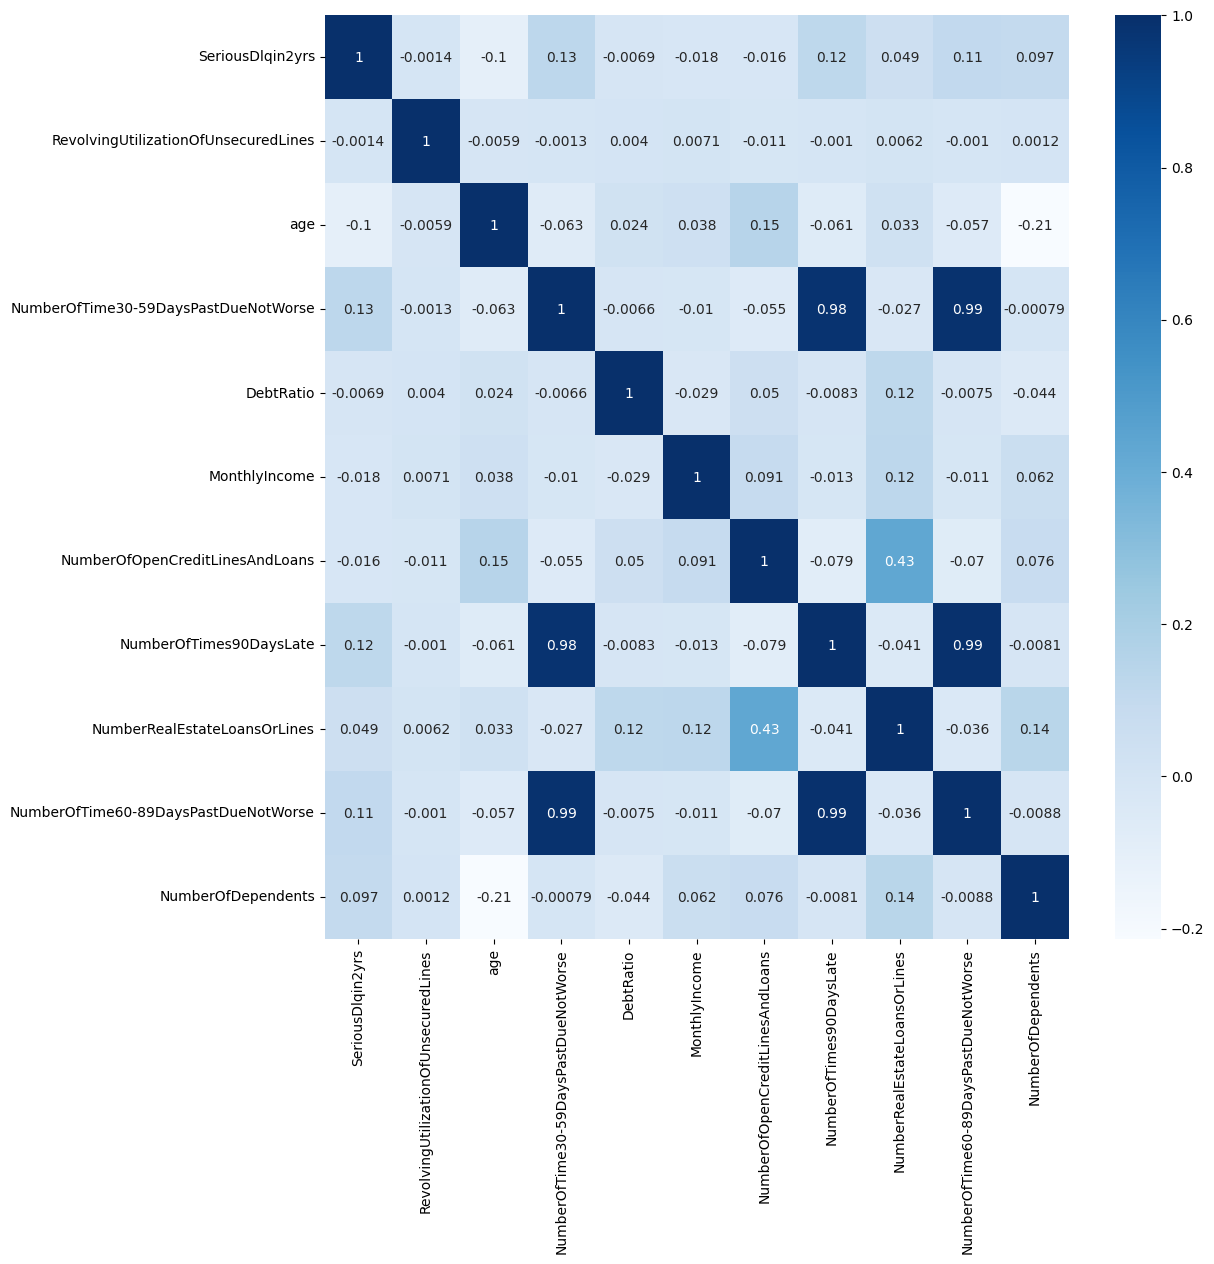

In [26]:
import seaborn as sb

plt.figure(figsize=(12, 12))
corr = DATA.corr()
sb.heatmap(corr, cmap='Blues', annot=True)

Существует значительная зависимость между **NumberOfOpenCreditLinesAndLoans** и **NumberRealEstateLoansOrLines**, так как они отражают наличие задолженностей. Объединим их в один признак наличия задолженностей **HasLoan**

In [ ]:
DATA['HasLoans'] = DATA['NumberOfOpenCreditLinesAndLoans'] + DATA['NumberRealEstateLoansOrLines']

In [ ]:
DATA['HasLoans'].describe()

In [ ]:
DATA['HasAlotLoans'] = DATA['HasLoans'].map(lambda x: 1 if x > 5 else 0)
DATA.drop(columns=['HasLoans', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines'], inplace=True)

**NumberOfTime30-59DaysPastDueNotWorse**, **NumberOfTimes90DaysLate** и **NumberOfTime60-89DaysPastDueNotWorse** так же сильно связаны между собой, поскольку обозначают просроченные выплаты. Объединим эти три признака в один - были ли опоздания с выплатами **HasLatePayments**

In [ ]:
DATA['NumbersOfLate'] = DATA['NumberOfTime30-59DaysPastDueNotWorse'] + DATA['NumberOfTime60-89DaysPastDueNotWorse'] + DATA['NumberOfTimes90DaysLate']

In [ ]:
DATA['HasLatePayments'] = DATA['NumbersOfLate'].map(lambda x: 1 if x > 0 else 0)
DATA.drop(columns=['NumbersOfLate','NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate'], inplace=True)

# Model Training

В данных присутствует дисбаланс классов тагрета:

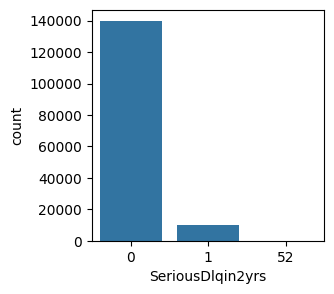

In [27]:
import seaborn as sns

plt.figure(figsize=(3, 3))
sns.countplot(x='SeriousDlqin2yrs', data=DATA)
plt.show()

То есть модель будет чаще видеть один класс, а следовательно и обучаться предсказывать именно его. 

Перед тем как начинать обучать модели, необходимо определиться с бизнес-целью:
- Возможно, банку, выдающему кредиты, важно выдавать кредиты только тем, кто их вернёт, и не выдавать кредиты тем, кто не вернет - тогда нужна высокая точность (Precision). 

- А если же банк хочет выдать кредиты наибольшему количеству клиентов, кто теоретически может вернуть кредит - нужна полнота (Recall).

Предположительно, из-за дисбаланса классов страдать будет именно точность предсказания положительного класса, поскольку его примеров значительно меньше. Поэтому сделаем упор на улучшение Precision, но также будем наблюдать Recall и f1, но не ROC-AUC

ROC-AUC измеряет способность модели различать классы, не учитывая их распределение. В условиях сильного дисбаланса классов, ROC-AUC может дать оптимистичную оценку, даже если модель хорошо классифицирует большинство классов, но плохо работает с меньшинством. Если, как в нашем случае, в данных очень мало положительных примеров по сравнению с отрицательными, модель может достигать высоких значений ROC-AUC, просто за счет правильного классифицирования большого числа отрицательных примеров, даже если её способность правильно классифицировать положительные примеры невелика.

В качестве моделей выберем бустинговые модели, поскольку они могут получить максимальную точность предсказания положительного класса

In [ ]:
X = DATA.drop(columns='SeriousDlqin2yrs')
y = DATA['SeriousDlqin2yrs']

In [ ]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.metrics import f1_score, recall_score, precision_score

In [ ]:
mlflow.set_experiment('Classifier for Target')

In [ ]:
# LGBM Classifier
def lgbm_objective(trial):
    with mlflow.start_run(run_name=f'LGBM_trial_{trial.number}', nested=True):
        
        learning_rate = trial.suggest_float('learning_rate', 0.001, 1)
        n_estimators = trial.suggest_int('n_estimators', 50, 500)
        max_depth = trial.suggest_int('max_depth', 2, 10)
        num_leaves = trial.suggest_int('num_leaves', 10, 150)
        
        mlflow.log_params({
            'learning_rate': learning_rate,
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'num_leaves': num_leaves
        })

        model = LGBMClassifier(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=max_depth,
            num_leaves=num_leaves,
            class_weight='balanced'
        )
        
        preds = cross_val_predict(model, X, y, cv=3)
        f1 = f1_score(y, preds)
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        
        mlflow.log_metrics({
            'f1': f1,
            'recall': recall,
            'precision': precision
        }, step=trial.number)
        
        return precision

# XGBoost Classifier
def xgboost_objective(trial):
    with mlflow.start_run(run_name=f'XGBoost_trial_{trial.number}', nested=True):
        
        learning_rate = trial.suggest_float('learning_rate', 0.01, 1.0)
        n_estimators = trial.suggest_int('n_estimators', 50, 1000)
        max_depth = trial.suggest_int('max_depth', 2, 10)
        
        mlflow.log_params({
            'learning_rate': learning_rate,
            'n_estimators': n_estimators,
            'max_depth': max_depth,
        })

        model = XGBClassifier(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=max_depth,
        )
        
        preds = cross_val_predict(model, X, y, cv=3)
        f1 = f1_score(y, preds)
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        
        mlflow.log_metrics({
            'f1': f1,
            'recall': recall,
            'precision': precision
        }, step=trial.number)
        
        return precision

In [ ]:
# LGBM Classifier
with mlflow.start_run(run_name='LGBM Classifier'):
    study = optuna.create_study(direction='maximize')
    study.optimize(lgbm_objective, n_trials=30)
    mlflow.log_metric('precision', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

# XGBoost Classifier
with mlflow.start_run(run_name='XGBoost Classifier'):
    study = optuna.create_study(direction='maximize')
    study.optimize(xgboost_objective, n_trials=30)
    mlflow.log_metric('precision', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')